#### importing libriries 

In [3]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F

#### Import data from kaggle

In [14]:
%pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]

Note: you may need to restart the kernel to use updated packages.


In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shreelakshmigp/cedardataset")

print("Path to dataset files:", path)

100%|██████████| 242M/242M [00:08<00:00, 29.5MB/s] 

Extracting files...


Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\shreelakshmigp\cedardataset\versions\1


Root data directory path

In [4]:
data_dir = r"C:\Users\PC\PycharmProjects\signatureRecognition\notebook\data"

#### Total number of classes

In [29]:
class_name = os.listdir(data_dir)
len(class_name)

2

In [30]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms as T, datasets

##### Checking cuda avaibility

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device : {}".format(device))

Device : cpu


#### transforming the data


In [32]:
data_transform = T.Compose([

    T.Resize(size=(224,224)), # Resizing the image to be 224 by 224
    T.RandomRotation(degrees=(-20,+20)), # Randomly rotate the images by +/- degreen Iage augmentation for each epoch
    T.ToTensor(), # Converting the dimension from (height, width, channel) to (channel, height, width) convention of Pytorch
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]) # Normalize by 3 means STD's of the image net, 3 channels
])


In [33]:
data = datasets.ImageFolder(data_dir, transform = data_transform)
total_count = len(data)
total_count

2640

In [34]:
data.classes

['Forged', 'Original']

#### Splitting the data

In [35]:
train_count = int(0.6 * total_count)
val_count = int(0.3 * total_count)
test_count = total_count - train_count - val_count
train_data, val_data, test_data = torch.utils.data.random_split(data, (train_count, val_count, test_count))

In [36]:
train_data.dataset


Dataset ImageFolder
    Number of datapoints: 2640
    Root location: C:\Users\PC\PycharmProjects\signatureRecognition\notebook\data
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [37]:
len(train_data.indices)

1584

In [38]:
len(val_data.indices)

792

In [39]:
len(test_data.indices)

264


### Defining helper functions




In [40]:
def show_image(image, label, get_denormalize = True):

    image = image.permute(1,2,0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406])
    std = torch.FloatTensor([0.229, 0.224, 0.225])

    if get_denormalize == True:
        image = image * std + mean
        image = np.clip(image, 0,1)
        plt.imshow(image)
        plt.title(label)

    else:
        plt.show(image)
        plt.title(label)


def show_grid(image, title = None):

    image = image.permute(1,2,0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406])
    std = torch.FloatTensor([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0,1)

    plt.figure(figsize = [15,15])
    plt.imshow(image)
    if title != None:
        plt.title(title)



def accuracy(y_pred, y_true):
    y_pred = F.softmax(y_pred, dim = 1)
    top_p,top_class = y_pred.topk(1, dim = 1)
    equals = top_class == y_true.view(*top_class.shape)

    return torch.mean(equals.type(torch.FloatTensor))

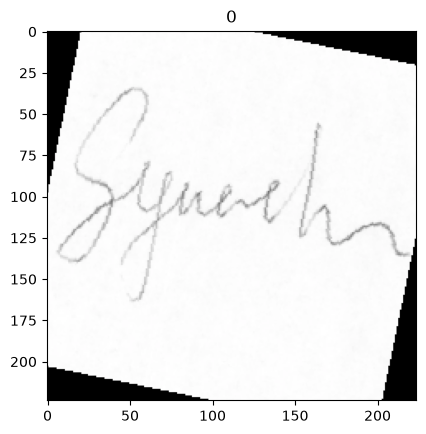

In [41]:
img, label = test_data[0]
show_image(img,label)

#### Data Loaders

In [42]:
trainloader = DataLoader(train_data, batch_size = 32, shuffle = True)
print("No. of batches in trainloader : {}".format(len(trainloader)))
print("No. of Total examples : {}".format(len(trainloader.dataset)))

valationloader = DataLoader(val_data, batch_size = 32, shuffle = True)
print("No. of batches in trainloader : {}".format(len(valationloader)))
print("No. of Total examples : {}".format(len(valationloader.dataset)))

testloader = DataLoader(test_data, batch_size = 32, shuffle = False)
print("No. of batches in trainloader : {}".format(len(testloader)))
print("No. of Total examples : {}".format(len(testloader.dataset)))

No. of batches in trainloader : 50
No. of Total examples : 1584
No. of batches in trainloader : 25
No. of Total examples : 792
No. of batches in trainloader : 9
No. of Total examples : 264


#### Model

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
import torchvision.transforms as transforms

In [44]:
from torchvision import models

weights = models.ResNet34_Weights.DEFAULT

print("Weights:", weights)
print("URL:", weights.url)
print("Avant téléchargement")

Weights: ResNet34_Weights.IMAGENET1K_V1
URL: https://download.pytorch.org/models/resnet34-b627a593.pth
Avant téléchargement


In [45]:
import urllib.request

url = weights.url

print("Test de connexion...")

try:
    with urllib.request.urlopen(url, timeout=15) as response:
        print("Connexion OK")
        print("Status:", response.status)
        print("Taille:", response.headers.get("Content-Length"))
except Exception as e:
    print("ERREUR:")
    print(type(e).__name__, e)

Test de connexion...
Connexion OK
Status: 200
Taille: 87319819


In [46]:
import torch
import os

print(torch.hub.get_dir())
print(os.path.join(torch.hub.get_dir(), "checkpoints"))

C:\Users\PC/.cache\torch\hub
C:\Users\PC/.cache\torch\hub\checkpoints


In [47]:
from torchvision import models

print("Début")

weights = models.ResNet34_Weights.DEFAULT
model = models.resnet34(
    weights=weights,
    progress=True
)

print("ResNet34 chargé !")

Début
ResNet34 chargé !


In [48]:
device = torch.device("cpu")

model.fc = nn.Sequential(
    nn.Dropout(0.1),
    nn.Linear(model.fc.in_features, len(class_name))
)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

In [49]:
def train(model, criterion, optimizer, train_dataloader, test_dataloader):

    total_train_loss = 0
    total_test_loss = 0
    
    model.train()
    with tqdm(train_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'training')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)
            output = model(images)

            loss = criterion(output, idxs)
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

    model.eval()
    with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)

            output = model(images)
            loss = criterion(output, idxs)
            total_test_loss += loss.item()

    train_acc = total_train_loss / len(train_data)
    test_acc = total_test_loss / len(val_data)
    print(f'Train loss: {train_acc:.4f} Test loss: {test_acc:.4f} ')

In [50]:
%%time
epochs=5
for i in range(epochs):
    print(f"Epoch {i+1}/{epochs}")
    train(model, criterion, optimizer, trainloader, valationloader)

Epoch 1/5


Train loss: 0.0081 Test loss: 0.0093 
Epoch 2/5


Train loss: 0.0004 Test loss: 0.0001 
Epoch 3/5


Train loss: 0.0003 Test loss: 0.0001 
Epoch 4/5


Train loss: 0.0002 Test loss: 0.0000 
Epoch 5/5


Train loss: 0.0003 Test loss: 0.0002 
CPU times: total: 2h 54min 27s
Wall time: 46min 36s


In [51]:
pwd

'C:\\Users\\PC\\PycharmProjects\\signatureRecognition\\notebook'

In [55]:
Path = r'C:\\Users\\PC\\PycharmProjects\\signatureRecognition\\notebook\\model.pt'
torch.save(model, Path)

In [57]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [58]:
Path = r'C:\Users\PC\PycharmProjects\signatureRecognition\notebook\model.pt'

model = torch.load(
    Path,
    map_location="cpu",
    weights_only=False
)

model.eval()

print("Model loaded successfully")

Model loaded successfully


In [59]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [61]:
def evaluate(model, criterion, optimizer, test_dataloader):

    total_test_loss = 0

    model.eval()

    with tqdm(test_dataloader, unit='batch', leave = False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)
            output = model(images)

            loss = criterion(output, idxs)
            total_test_loss += loss.item()

    test_acc = total_test_loss/len(val_data)
    print(f'Test loss: {test_acc:.4f}')
    

In [62]:
evaluate(model, criterion, optimizer, testloader)

Test loss: 0.0001


In [63]:
label_names = data.classes
label_names

['Forged', 'Original']

In [67]:
from PIL import Image

# Load the image and preprocess it
image = Image.open(r'C:\Users\PC\PycharmProjects\signatureRecognition\notebook\data\Original\original_41_14.png')
preprocess = transforms.Compose([
    transforms.Resize(size = (224,224)),
    transforms.Grayscale(3),
    transforms.ToTensor()
])

image = preprocess(image)
image  = image[:3]

# Convert the image to a PyTorch tensor and send it to the device
image = image.unsqueeze(0).to(device)

# Make the prediction
with torch.no_grad():
    logits = model(image)
    probs = torch.softmax(logits, dim=1)
    pred_label = torch.argmax(probs, dim=1)

# Print the prediction
print(f'Predicted label: {pred_label.item()}')

# Map the predicted label to the corresponding class name
predicted_class_name = label_names[pred_label.item()]

# Print the predicted class name
print(f'Predicted class name: {predicted_class_name}')

Predicted label: 1
Predicted class name: Original
